In [47]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("faizalkarim/flood-area-segmentation")

print("Path to dataset files:", path)

Path to dataset files: /Users/sherpro/.cache/kagglehub/datasets/faizalkarim/flood-area-segmentation/versions/1


In [72]:
metadata_path = os.path.join(path, "metadata.csv")
df = pd.read_csv(metadata_path)

In [49]:
img_dir_name = "Image" if "Image" in os.listdir(path) else "image"
mask_dir_name = "Mask" if "Mask" in os.listdir(path) else "mask"

In [50]:
image_paths = [os.path.join(path, img_dir_name, img) for img in df['Image']]
mask_paths = [os.path.join(path, mask_dir_name, mask) for mask in df['Mask']]

In [51]:
print(f"\nSuccessfully verified and mapped {len(df)} asset paths.")


Successfully verified and mapped 290 asset paths.


In [52]:
from sklearn.model_selection import train_test_split

X_train_paths, X_test_paths, y_train_paths, y_test_paths = train_test_split(
    image_paths, 
    mask_paths, 
    test_size=0.2, 
    random_state=42
)

print(f"Training pairs: {len(X_train_paths)} | Testing pairs: {len(X_test_paths)}")

Training pairs: 232 | Testing pairs: 58


In [53]:
from PIL import Image
import numpy as np
from tqdm import tqdm

def load_data(path_list, gray=False, img_size=256):
    data = []
    desc_text = "Loading Masks" if gray else "Loading Images"
    
    for file_path in tqdm(path_list, desc=desc_text):
        try:
            img = Image.open(file_path)
            img = img.convert('L') if gray else img.convert('RGB')
            img = img.resize((img_size, img_size))
            
            img_array = np.array(img) / 255.0
            data.append(img_array)
        except Exception as e:
            print(f"\nError loading asset at {file_path}: {e}")
            
    data = np.array(data)
    if gray and len(data.shape) == 3:
        data = np.expand_dims(data, axis=-1)
        
    return data

In [57]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

In [68]:
IMG_HEIGHT, IMG_WIDTH = 256, 256 
BATCH_SIZE = 32 

# Run the conversions
X_train = load_data(X_train_paths, gray=False, img_size=IMG_SIZE)
X_test = load_data(X_test_paths, gray=False, img_size=IMG_SIZE)

y_train = load_data(y_train_paths, gray=True, img_size=IMG_SIZE)
y_test = load_data(y_test_paths, gray=True, img_size=IMG_SIZE)

print("\n--- Processing Finished Successfully ---")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}  | y_test shape:  {y_test.shape}")

Loading Masks: 100%|██████████| 58/58 [00:00<00:00, 130.94it/s]



--- Processing Finished Successfully ---
X_train shape: (232, 256, 256, 3) | y_train shape: (232, 256, 256, 1)
X_test shape:  (58, 256, 256, 3)  | y_test shape:  (58, 256, 256, 1)


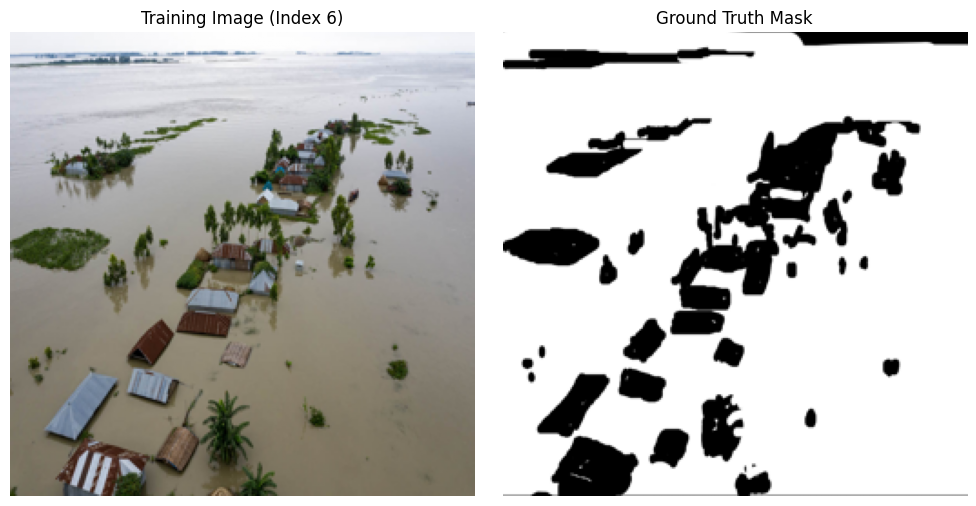

In [69]:
import matplotlib.pyplot as plt
import random

# Pick a random sample index
sample_idx = random.randint(0, len(X_train) - 1)

plt.figure(figsize=(10, 5))

# Plot original image
plt.subplot(1, 2, 1)
plt.imshow(X_train[sample_idx])
plt.title(f"Training Image (Index {sample_idx})")
plt.axis("off")

# Plot corresponding mask
plt.subplot(1, 2, 2)
plt.imshow(y_train[sample_idx].squeeze(), cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [70]:
def unet_model(input_size=(IMG_HEIGHT, IMG_WIDTH, 3)):
    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(c4)

    # Decoder
    u1 = UpSampling2D((2, 2))(c4)
    u1 = Concatenate()([u1, c3])
    c5 = Conv2D(64, (3, 3), activation='relu', padding='same')(u1)
    c5 = Conv2D(64, (3, 3), activation='relu', padding='same')(c5)

    u2 = UpSampling2D((2, 2))(c5)
    u2 = Concatenate()([u2, c2])
    c6 = Conv2D(32, (3, 3), activation='relu', padding='same')(u2)
    c6 = Conv2D(32, (3, 3), activation='relu', padding='same')(c6)

    u3 = UpSampling2D((2, 2))(c6)
    u3 = Concatenate()([u3, c1])
    c7 = Conv2D(16, (3, 3), activation='relu', padding='same')(u3)
    c7 = Conv2D(16, (3, 3), activation='relu', padding='same')(c7)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c7)

    model = Model(inputs, outputs)
    return model

# Create model
model = unet_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 256, 256,  │        448 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 256, 256,  │      2,320 │ conv2d_30[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 128, 128,  │          0 │ conv2d_31[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 128, 128,  │      4,640 │ max_pooling2d_6[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_32[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 64, 64,    │          0 │ conv2d_33[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_7[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_34[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 32, 32,    │          0 │ conv2d_35[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_8[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_36[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_6     │ (None, 64, 64,    │          0 │ conv2d_37[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 64, 64,    │          0 │ up_sampling2d_6[… │
│ (Concatenate)       │ 192)              │            │ conv2d_35[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 64, 64,    │    110,656 │ concatenate_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_38[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_7     │ (None, 128, 128,  │          0 │ conv2d_39[0][0] 

 Total params: 487,297 (1.86 MB)

 Trainable params: 487,297 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BATCH_SIZE = 16
MAX_EPOCHS = 30

# Smart monitoring additions
callbacks = [
    # Halts training if validation loss stops improving for 5 straight epochs
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=5, 
        restore_best_weights=True
    ),
    # Saves the absolute best weights configuration to disk automatically
    tf.keras.callbacks.ModelCheckpoint(
        'best_flood_unet.keras', 
        monitor='val_loss', 
        save_best_only=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=BATCH_SIZE,
    epochs=MAX_EPOCHS,
    callbacks=callbacks
)

Starting U-Net optimization loop...
Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.5640 - loss: 0.6800 - val_accuracy: 0.7319 - val_loss: 0.6611
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.6934 - loss: 0.6064 - val_accuracy: 0.7450 - val_loss: 0.5327
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7447 - loss: 0.5316 - val_accuracy: 0.7420 - val_loss: 0.5255
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7728 - loss: 0.4647 - val_accuracy: 0.7712 - val_loss: 0.4601
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7824 - loss: 0.4410 - val_accuracy: 0.7691 - val_loss: 0.4627
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7851 - loss: 0.4313 - val_accuracy: 0.7403 - val_loss: 0.5326
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.7757 - loss: 0.4563 - val_accuracy: 0.7903 - val_loss: 0.4163
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.7761 - loss: 0.443